In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [15]:
df=pd.read_csv("Titanic-dataset.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [16]:
df.head()

df.info()

df.describe()

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  49 non-null     int64  
 1   Survived     49 non-null     int64  
 2   Pclass       49 non-null     int64  
 3   Name         49 non-null     str    
 4   Sex          49 non-null     str    
 5   Age          35 non-null     float64
 6   SibSp        49 non-null     int64  
 7   Parch        49 non-null     int64  
 8   Ticket       49 non-null     str    
 9   Fare         49 non-null     float64
 10  Cabin        9 non-null      str    
 11  Embarked     49 non-null     str    
dtypes: float64(2), int64(5), str(5)
memory usage: 4.7 KB


(49, 12)

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

In [20]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [21]:
df[df["Age"] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [26]:
df["Sex"] = df["Sex"].str.lower()
print(df["Sex"])

0       male
1     female
2     female
3     female
4       male
5       male
6       male
7       male
8     female
9     female
10    female
11    female
12      male
13      male
14    female
15    female
16      male
17      male
18    female
19    female
20      male
21      male
22    female
23      male
24    female
25    female
26      male
27      male
28    female
29      male
30      male
31    female
32    female
33      male
34      male
35      male
36      male
37      male
38    female
39    female
40    female
41    female
42      male
43    female
44    female
45      male
46      male
47    female
48      male
Name: Sex, dtype: str


<Axes: xlabel='Ticket'>

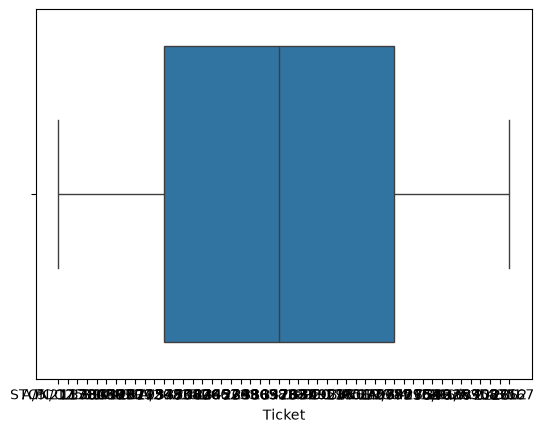

In [28]:
sns.boxplot(x=df["Ticket"])

In [29]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

In [31]:
scaler = StandardScaler()

df["Fare"] = scaler.fit_transform(df[["Fare"]])

In [ ]:
df["Price_per_sqft"] = df["Price"] / df["Area"]

In [33]:
X = df.drop("Ticket", axis=1)

y = df["Ticket"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
df.to_csv("titanic.csv", index=False)